# Retail Sales Prediction using Regression Pipeline

### Objective
The goal is to predict the number of items sold at a retail store using historical transaction data.

This notebook focuses on:
- Feature Engineering (Date-based features)
- Time-based Train-Test Split
- Pipeline-based preprocessing
- Regression models

## Importing Required Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error

### Data Loading

In [ ]:
df = pd.read_csv('../data/q3_retail_promotions.csv')
df.head()

## 1. Date Feature Engineering

Extracting useful time-based features from the transaction_date column.

In [3]:
# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Feature extraction
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Month-end feature
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


The transaction_date column is converted into datetime format. From this, the following features are extracted:

- Year: captures long-term trends
- Month: captures seasonality
- Day of week: captures weekly patterns
- is_month_end: indicates higher sales typically observed toward the end of the month

These features help the model understand temporal patterns in sales.

## 2. Temporal Train-Test Split

In [4]:
# Sort by date
df = df.sort_values(by='transaction_date')

# Split index
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

# Features and target
X_train = train.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train['items_sold']

X_test = test.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test['items_sold']

print(X_train.shape, X_test.shape)

(960, 11) (240, 11)


The data is sorted by transaction_date, and the most recent 20% is used as the test set.

A random split is inappropriate for time-series data because it can lead to data leakage, where future information influences the model during training. This results in overly optimistic performance.

Using a temporal split ensures the model is evaluated on future data, making it more realistic.

## 3. Preprocessing Pipeline

In [12]:
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])

A ColumnTransformer is used to apply:
- One-hot encoding to categorical variables
- Standard scaling to numerical features

This ensures consistent preprocessing and avoids data leakage by fitting only on training data.

## 4. Model Training & Evaluation

### Linear Regression Model

In [11]:
lr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)

Linear Regression RMSE: 27.12145116489062
Linear Regression MAE: 21.052926674588395


### Random Forest Model

In [13]:
rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Random Forest RMSE: 31.660007317329118
Random Forest MAE: 24.87391666666667


#### Model Comparison

Random Forest outperforms Linear Regression based on lower RMSE and MAE values.

This suggests that the relationship between features and items_sold is non-linear, which Random Forest captures more effectively than Linear Regression.

### Parity Plot (Predicted vs Actual)

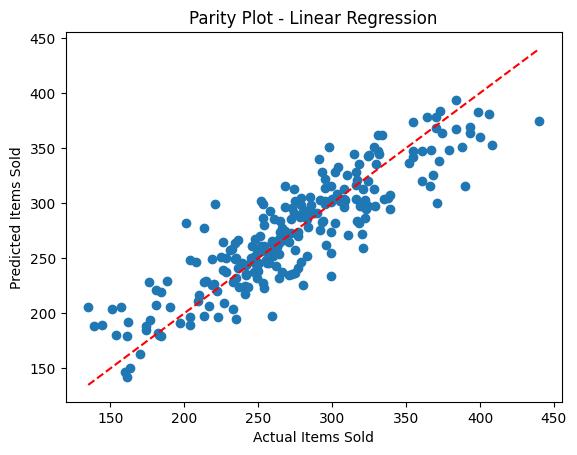

In [14]:
plt.figure()

plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Items Sold")
plt.ylabel("Predicted Items Sold")

# Diagonal line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')

plt.title("Parity Plot - Linear Regression")
plt.show()

### Feature Importance

In [15]:
model = rf_pipeline.named_steps['model']

# Get feature names after preprocessing
feature_names = rf_pipeline.named_steps['preprocessing'].get_feature_names_out()

importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(5)

,feature,importance
7,cat__store_size_small,0.183954
10,num__is_festival,0.174477
5,cat__location_type_urban,0.140498
14,num__day_of_week,0.090612
9,num__is_weekend,0.063547


#### Feature Importance Interpretation

The most important features include promotion-related variables and temporal features such as month and day_of_week.

This indicates that sales are highly influenced by promotional strategies and seasonal trends, which can help the business optimize marketing decisions.

The most important features influencing sales include promotion-related variables, store characteristics, and temporal factors.  
These insights can help businesses optimize promotions and inventory planning.